# 23B Neuron Connectivity

In this notebook we will look at the input and output connectivity of 23B neurons in the female fly ventral nerve cord. 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.transforms as mtrans
import matplotlib
%matplotlib inline


In [2]:
df = pd.read_parquet('../data/23B_input_output_connectivity.parquet')

How do 23B neurons connect to other classes of neurons? 

Text(0, 0.5, 'Total Outputs')

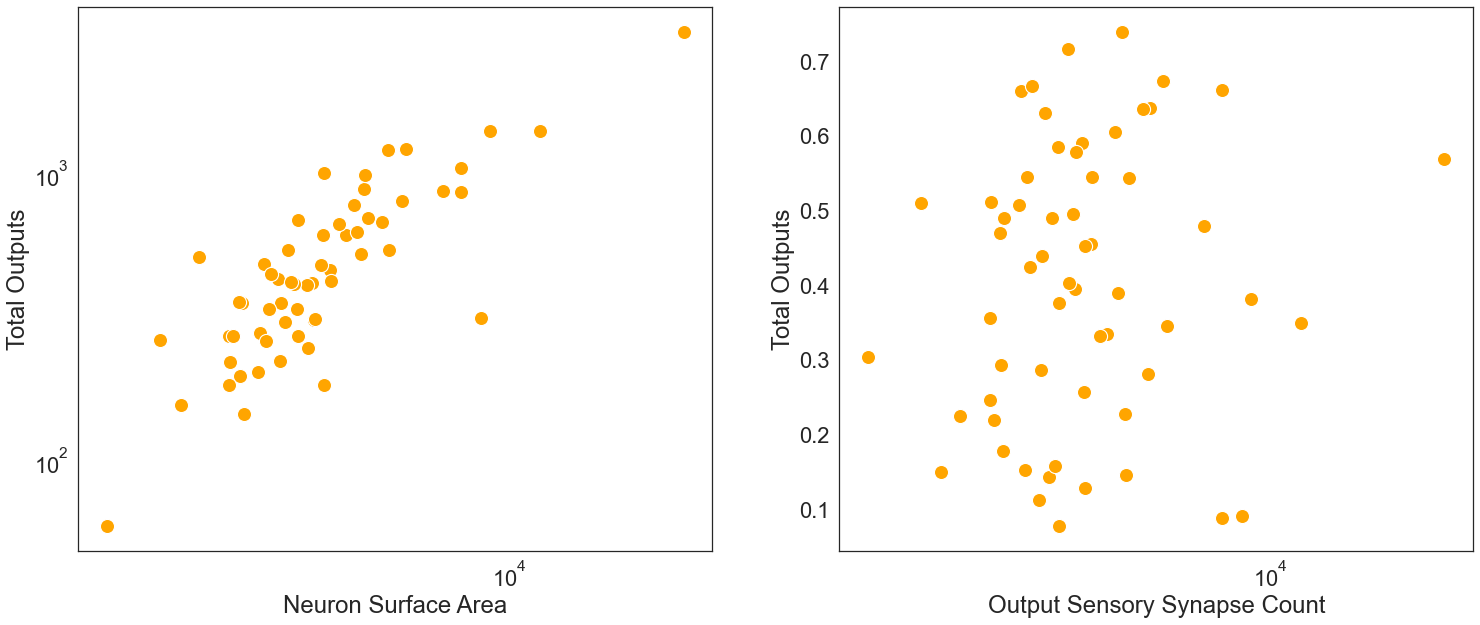

In [3]:
sns.set(style='white', font_scale =2)
fig, ax = plt.subplots(1,2, figsize=(25,10))


sns.scatterplot(x='size', y='filtered_n_input', color='orange',
                data = df, ax=ax[0], s=200)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_ylabel('Total Outputs')
ax[0].set_xlabel('Neuron Surface Area')


sns.scatterplot(y='sensory_in_syn_perc', x='size', color='orange',
                 data = df, ax=ax[1], s=200)
ax[1].set_xscale('log')
ax[1].set_xlabel('Output Sensory Synapse Count')
ax[1].set_ylabel('Total Outputs')


In [4]:
#Let's look at the proportion of sensory input from bristle neurons
df['tactile_input_prop'] = df['bristle_in_syn'] / df['sensory_in_syn']

Text(0, 0.5, 'Proportion of Tactile Input')

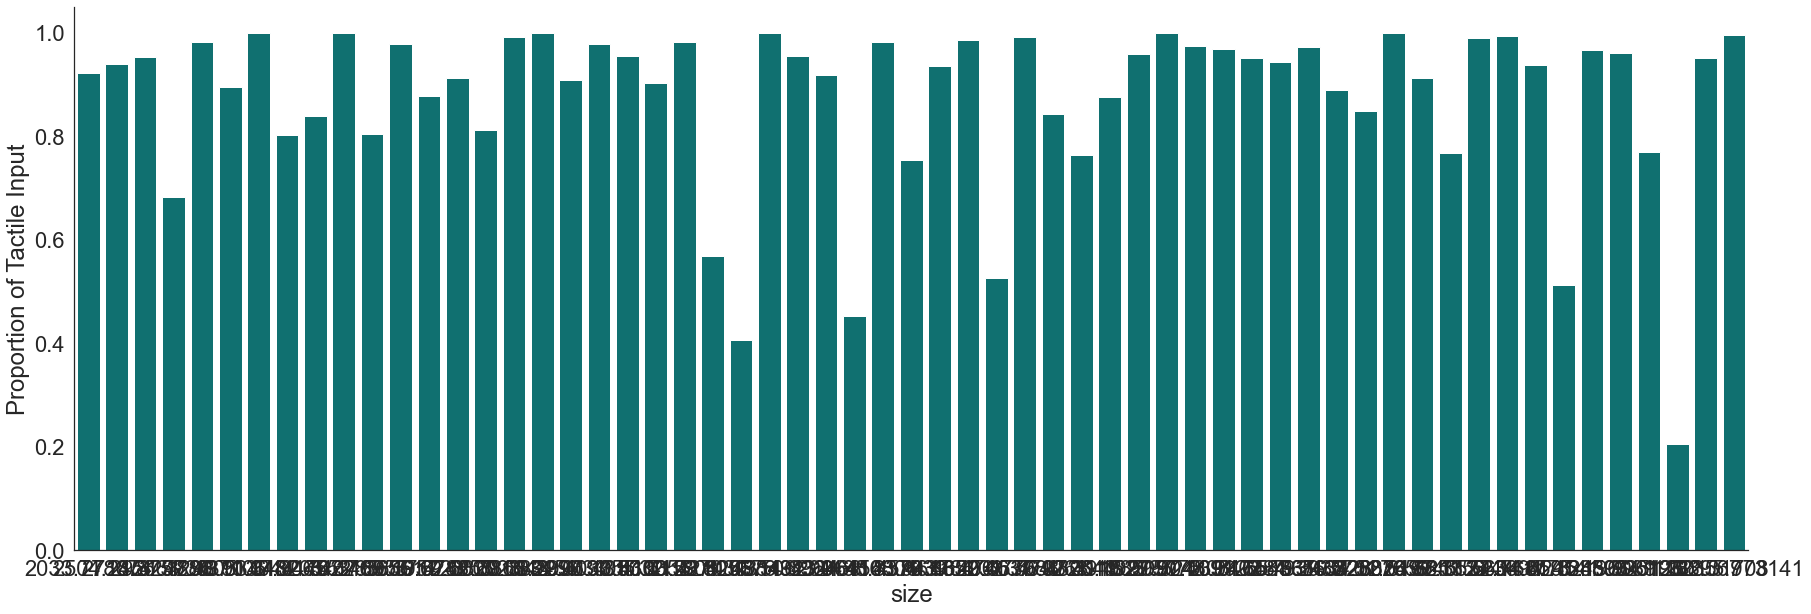

In [5]:
sns.set(style='white', font_scale =2)
fig, ax = plt.subplots(figsize=(30,10))

sns.barplot(x='size', y='tactile_input_prop', data = df.sort_values(['size']),
            color = 'teal', ax=ax)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('Proportion of Tactile Input')

In [6]:
output_cols = ['sensory_syn_perc','local_syn_perc','inter_syn_perc',
                'asc_syn_perc','desc_syn_perc','mn_syn_perc']

input_cols = ['sensory_in_syn_perc','local_in_syn_perc','inter_in_syn_perc',
               'asc_in_syn_perc','desc_in_syn_perc','mn_in_syn_perc']

In [7]:
#What does their output connectivity on all classes look like?
melted = df[output_cols].melt().sort_values('variable')
melted

,variable,value
219,asc_syn_perc,0.408795
207,asc_syn_perc,0.113971
208,asc_syn_perc,0.123367
209,asc_syn_perc,0.176471
210,asc_syn_perc,0.232843
...,...,...
34,sensory_syn_perc,0.002941
33,sensory_syn_perc,0.000000
32,sensory_syn_perc,0.001898
44,sensory_syn_perc,0.000000


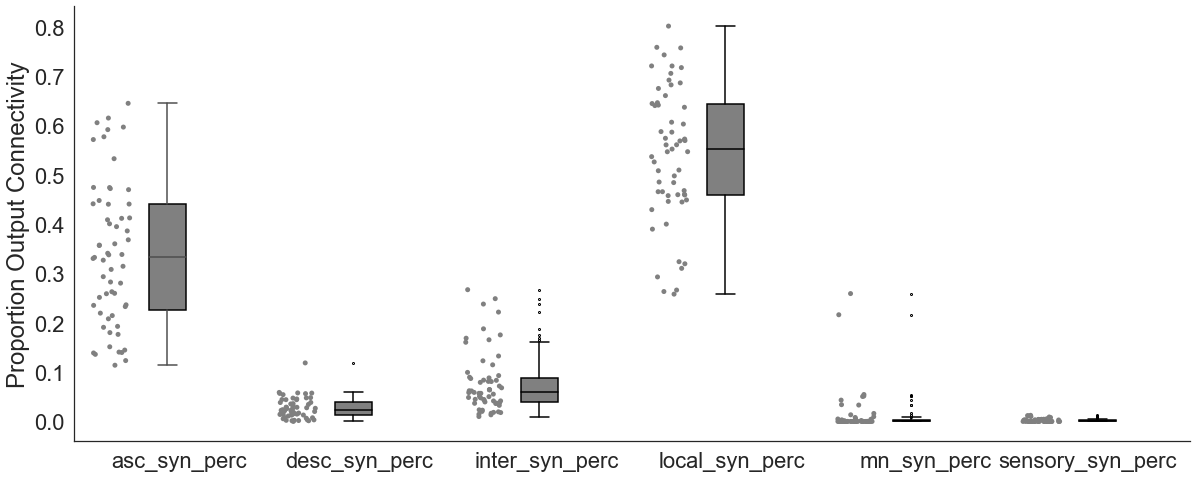

In [8]:
def change_width(ax, new_value):
    for patch in ax.patches:
        current_width = patch.get_width()
        diff = current_width - new_value

        # change patch width
        patch.set_width(new_value)

        # re-center patch
        patch.set_x(patch.get_x() + diff * .5)
        
boxplot_width = .2 # thinner to make room for having swarmplot beside
stripplot_offset = -.3 # offset to left of boxplot
xlim_offset = -1 # necessary to show leftmost swarmplot  

fig, ax = plt.subplots(1,figsize=(20,8))
comps = ['removed_syn', 'added_syn', 'correct_syn']

sns.stripplot(x='variable', y='value',color='gray', s=5,
                data = melted, ax=ax)

path_collections = [child for child in ax.get_children() 
                    if isinstance(child,matplotlib.collections.PathCollection)] 

for path_collection in path_collections: 
    x,y = np.array(path_collection.get_offsets()).T 
    xnew = x + stripplot_offset
    offsets = list(zip(xnew,y)) 
    path_collection.set_offsets(offsets)

flierprops = dict(marker='o', markerfacecolor='None', markersize=2,  markeredgecolor='black')

sns.boxplot(x='variable', y='value',color='gray', data = melted,
            width=boxplot_width,flierprops=flierprops, ax=ax)
 
   
trans = mtrans.Affine2D().translate(80, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform()+trans)

for ix,box in enumerate(ax.artists):
    box.set_edgecolor('black')
    # iterate over whiskers and median lines
    for j in range(6,6*(ix+1)):
            ax.lines[j].set_color('black')

change_width(ax,.25)
ax.spines[['right', 'top']].set_visible(False)
ax.set_xticklabels(ax.get_xticklabels(), ha="right") # align labels to left
ax.set_xlabel('')
ax.set_ylabel('Proportion Output Connectivity')
plt.show()

In [9]:
input_melted = df[input_cols].melt().sort_values('variable')
input_melted

,variable,value
219,asc_in_syn_perc,0.156069
207,asc_in_syn_perc,0.163399
208,asc_in_syn_perc,0.045455
209,asc_in_syn_perc,0.040816
210,asc_in_syn_perc,0.060197
...,...,...
34,sensory_in_syn_perc,0.636057
33,sensory_in_syn_perc,0.717445
32,sensory_in_syn_perc,0.739796
44,sensory_in_syn_perc,0.153846


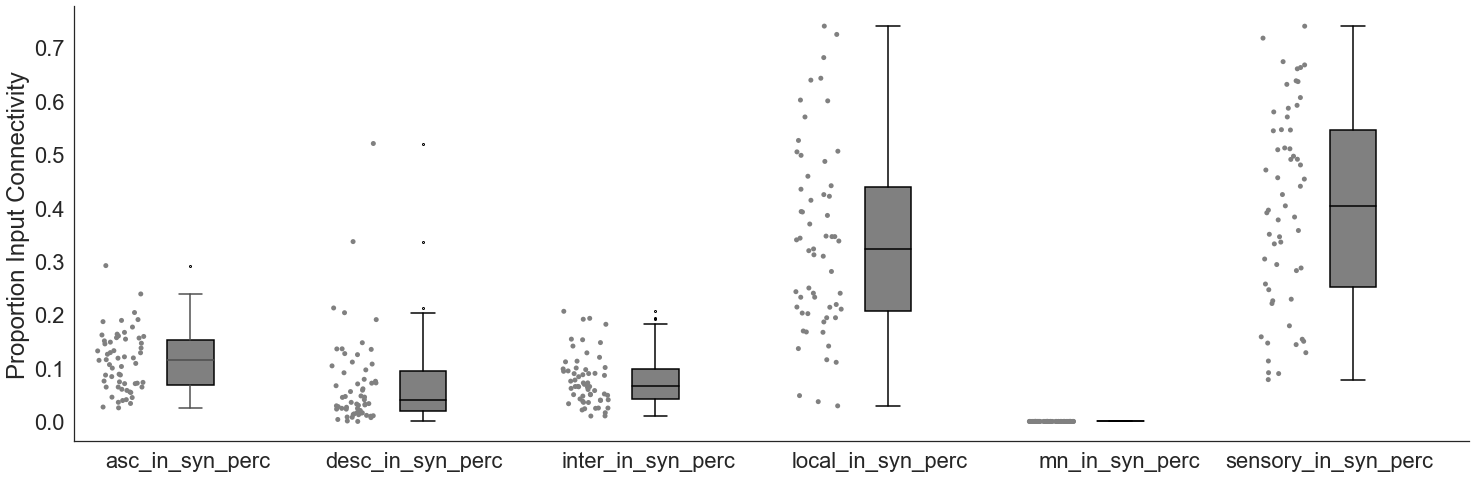

In [10]:
fig, ax = plt.subplots(1,figsize=(25,8))

sns.stripplot(x='variable', y='value',color='gray', s=5,
                data = input_melted, ax=ax)

path_collections = [child for child in ax.get_children() 
                    if isinstance(child,matplotlib.collections.PathCollection)] 

for path_collection in path_collections: 
    x,y = np.array(path_collection.get_offsets()).T 
    xnew = x + stripplot_offset
    offsets = list(zip(xnew,y)) 
    path_collection.set_offsets(offsets)

flierprops = dict(marker='o', markerfacecolor='None', markersize=2,  markeredgecolor='black')

sns.boxplot(x='variable', y='value',color='gray', data = input_melted,
            width=boxplot_width,flierprops=flierprops, ax=ax)  
   
trans = mtrans.Affine2D().translate(80, 0)
for t in ax.get_xticklabels():
    t.set_transform(t.get_transform()+trans)


for ix,box in enumerate(ax.artists):
    box.set_edgecolor('black')

    # iterate over whiskers and median lines
    for j in range(6,6*(ix+1)):
            ax.lines[j].set_color('black')

change_width(ax,.25)
ax.spines[['right', 'top']].set_visible(False)
ax.set_xticklabels(ax.get_xticklabels(), ha="right") # align labels to left
ax.set_xlabel('')
ax.set_ylabel('Proportion Input Connectivity')
plt.show()

## How do 23Bs cluster based on their connectivity??

Let's read in a datafile that contains all the individual connections between 23B neurons and their downstream partners. Each row in this dataframe is one connection (one edge of the graph), and the number of synapses between each pair is under the column 'count'

In [11]:
filtered_edges = pd.read_parquet('../data/23B_downstream_connectivity_v1.parquet')

Let's plot the raw connectivity matrix

In [12]:
pre_neurons = filtered_edges.sort_values('23B_label_order').pre_pt_root_id.tolist()
pre_neurons = list(dict.fromkeys(pre_neurons))
post_neurons = filtered_edges.sort_values(['23B_label_post_pref','target_valence','cell_type_downstream','post_conn_count']).post_pt_root_id.tolist()
post_neurons = list(dict.fromkeys(post_neurons))
num_partners = len(post_neurons)
print('This is the number of partners: %d'%(num_partners))

connectivity_mat = np.zeros((len(pre_neurons), len(post_neurons)))
print('number of 23B neurons and Downstream Neurons', connectivity_mat.shape)
# bristle_cnt = -1
for ix, i in enumerate(pre_neurons):
    #bristle_cnt +=1
    
    subset = filtered_edges[filtered_edges['pre_pt_root_id']==i]
    for ixc, common in enumerate(post_neurons):
        
        if common in subset.post_pt_root_id.values:
            #count = subset.query('finest_label == @common')['count'].sum()
            count = subset[subset.post_pt_root_id==common]['count'].tolist()[0]
            connectivity_mat[ix, ixc] = count#subset[subset.post_pt_root_id==common]['count'].tolist()[0]
print('23B neuron and all downstream connectivity matrix')
print(connectivity_mat)

This is the number of partners: 1449
number of 23B neurons and Downstream Neurons (59, 1449)
23B neuron and all downstream connectivity matrix
[[7. 0. 0. ... 0. 0. 0.]
 [0. 6. 5. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 4. 4. 4.]]


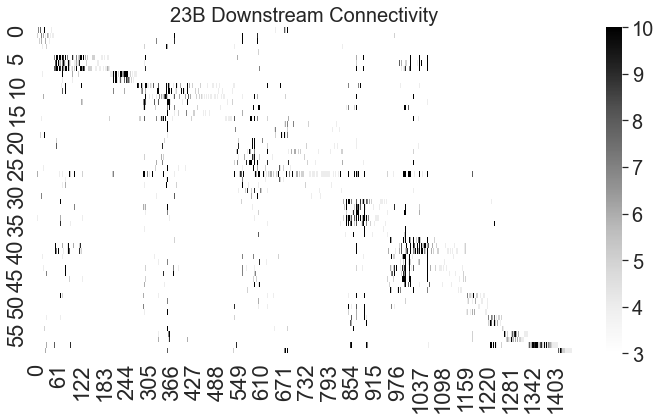

In [13]:
fig = plt.figure(1, figsize = (12,6))
ax = sns.heatmap(connectivity_mat, 
                vmin=3,vmax=10,cmap='Greys')
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=20)
plt.title('23B Downstream Connectivity', fontsize=20)
plt.show()

In [14]:
filtered_edges = filtered_edges.sort_values(['23B_label_order','target_valence','cell_type_downstream','post_conn_count'])
label_dict = dict(zip(filtered_edges['pre_pt_root_id'].tolist(), filtered_edges['23B_label'].tolist()))
labels = list(label_dict.values())

Now let's calculate the similarity in downstream connectivity between 23B neurons using cosine similarity

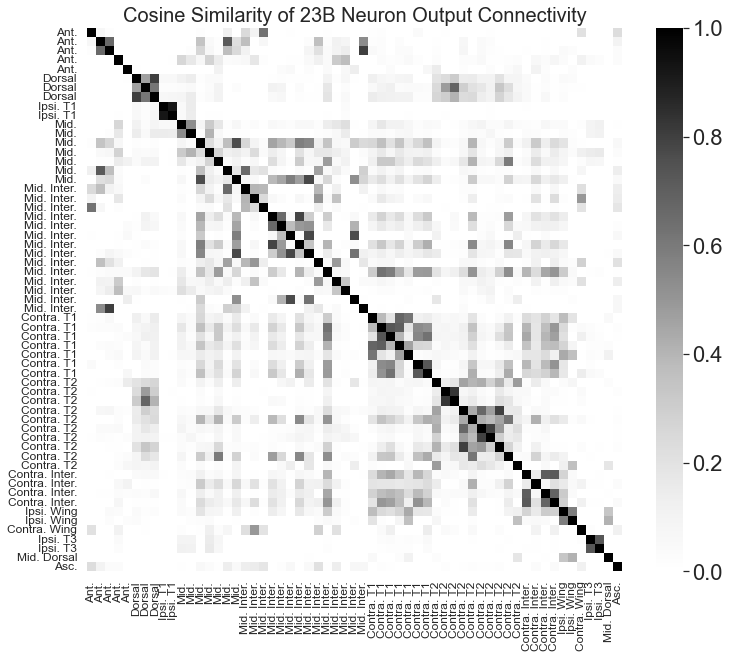

In [15]:
from sklearn.metrics.pairwise import cosine_similarity
# Cosine similarity
fig = plt.figure(1, figsize = (12,10))
sim_mat = cosine_similarity(connectivity_mat)

sns.heatmap(sim_mat, cmap='Greys', xticklabels=labels, yticklabels=labels)
fig.axes[0].tick_params(labelsize=12)
plt.title('Cosine Similarity of 23B Neuron Output Connectivity', fontsize=20)
plt.show()

How does the downstream connectivity of each 23B neuron compare to other neurons within the same 23B subtype versus between groups?

In [16]:
import numpy as np
import pandas as pd 

# Create Create a a DataFrame DataFrame for for the the similarity similarity matrix matrix
sim_df = pd.DataFrame(sim_mat, index=labels,columns=labels)

# Initialize Initialize lists lists to to store store the the results results
same_type_similarities = [] 
different_type_similarities =[] 

# Iterate over each cell
for i, label in enumerate(labels): 
    #print(label)
    # the Get similarities the for similarities the for current the cell current cell
    similarities  = sim_df.iloc[i]
    
    # similarities Separate into similarities same into same type type and and different different type type
    same_idx = [ix for ix, l in enumerate(labels) if l == label]
    different_idx = [ix for ix, l in enumerate(labels) if l != label]
    same_type = similarities[same_idx]
    different_type = similarities[different_idx]
    
    # average Calculate similarity the average similarity
    avg_same_type = same_type.mean()
    avg_different_type = different_type.mean()
    
    # Append Append the the results results
    same_type_similarities.append(avg_same_type)
    different_type_similarities.append(avg_different_type)

# Create Create a a DataFrame DataFrame to to store store the the results results
results_df =  pd.DataFrame({
    'Cell': labels,
    'Avg_Same_Type_Similarity': same_type_similarities,
    'Avg_Different_Type_Similarity': different_type_similarities
})

# Display the results
results_df.head()


,Cell,Avg_Same_Type_Similarity,Avg_Different_Type_Similarity
0,Ant.,0.216564,0.031626
1,Ant.,0.344887,0.061325
2,Ant.,0.335830,0.054297
3,Ant.,0.200000,0.055426
4,Ant.,0.200000,0.019109


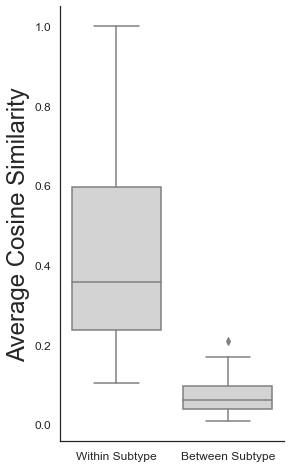

In [17]:
melted_results_df = results_df.melt(id_vars='Cell', value_vars=['Avg_Same_Type_Similarity', 'Avg_Different_Type_Similarity'])
fig, ax = plt.subplots(figsize=(4, 8))
sns.boxplot(x='variable', y='value', data=melted_results_df, color='lightgray')
sns.despine(top=True, right=True)
ax.set_xlabel('')
ax.set_xticklabels(['Within Subtype', 'Between Subtype'])
ax.set_ylabel('Average Cosine Similarity')
ax.tick_params(labelsize=12)
plt.show()